# Self-Updating Daily Outlooks

📂 Using latest MEAN parquet file:
/nfs/spare11/dharkin/NWS_Lapenta_Project/correct_parquet_data/Operational_data/2026/03/05/Operational_GEFS_12z_20260305_mean.parquet
Rows after spatial filter: 13908


/knight/jan25/envs/jan25_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


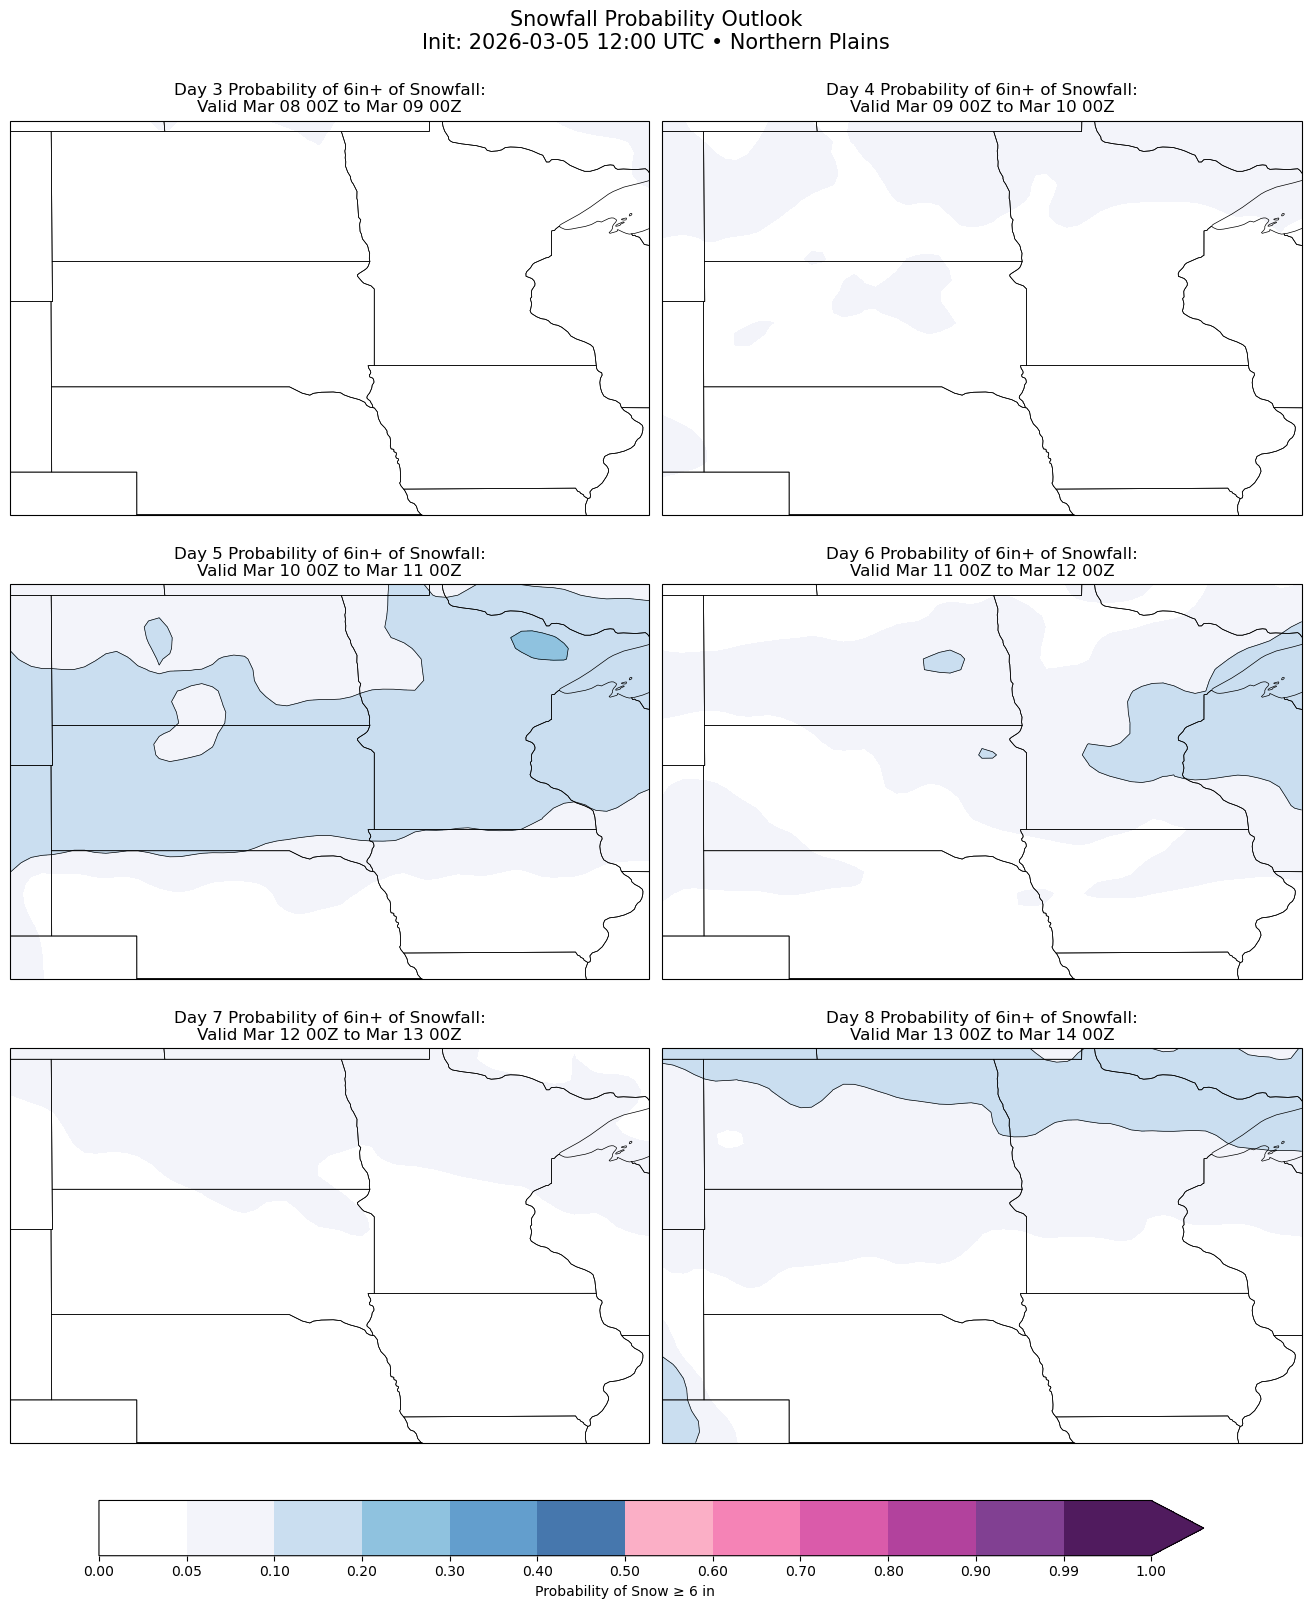

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.ndimage import gaussian_filter

# =====================================================
# CONFIG
# =====================================================

BASE_DIR = Path("/nfs/spare11/dharkin/NWS_Lapenta_Project/correct_parquet_data/Operational_data")
MODEL = Path("/nfs/spare11/dharkin/NWS_Lapenta_Project/models/rf_year2015-2019_6in_neighborhood_reshaped.joblib")

LAT_MIN, LAT_MAX = 40.0, 49.25
LON_MIN, LON_MAX = -105.0, -90.0
THRESH_CM = 15.24  # 6 inches
SMOOTH_SIGMA = 1.0

# =====================================================
# 1️⃣ Find latest MEAN parquet file
# =====================================================

all_parquets = list(BASE_DIR.rglob("*mean*.parquet"))

if not all_parquets:
    raise FileNotFoundError("No MEAN parquet files found.")

def extract_date(path):
    match = re.search(r"(\d{8})", path.name)
    if match:
        return pd.to_datetime(match.group(1), format="%Y%m%d")
    return pd.Timestamp.min

all_parquets_sorted = sorted(all_parquets, key=extract_date)
PARQUET = all_parquets_sorted[-1]

print(f"📂 Using latest MEAN parquet file:\n{PARQUET}")

# =====================================================
# 2️⃣ Load data
# =====================================================

df = pd.read_parquet(PARQUET)

df["longitude"] = df["longitude"].apply(
    lambda lon: lon - 360 if lon > 180 else lon
)

# =====================================================
# 3️⃣ Subset domain
# =====================================================

geo_mask = (
    df["latitude"].between(LAT_MIN, LAT_MAX) &
    df["longitude"].between(LON_MIN, LON_MAX)
)

df = df.loc[geo_mask]
print(f"Rows after spatial filter: {len(df)}")

# =====================================================
# 4️⃣ Compute forecast lead
# =====================================================

df["valid_time"] = pd.to_datetime(df["valid_time"])
df["init_time"] = pd.to_datetime(df["init_time"])

df["forecast_lead_hours"] = (
    (df["valid_time"] - df["init_time"]).dt.total_seconds() // 3600
)

df = df[df["forecast_lead_hours"].between(60, 204)]

if df.empty:
    raise ValueError("No forecast data found for hours 60–204.")

init_time = df["init_time"].min()

# =====================================================
# 5️⃣ Load trained model
# =====================================================

bundle = joblib.load(MODEL)
rf = bundle["model"]
feature_cols = bundle["features"]

for col in feature_cols:
    if col not in df.columns:
        df[col] = 0

X = df[feature_cols].astype("float32").fillna(0)
df["prob"] = rf.predict_proba(X)[:, 1]

# =====================================================
# 6️⃣ Build snow mask
# =====================================================

if "snowfall_nohrsc_m" in df.columns:
    df["snow_cm"] = df["snowfall_nohrsc_m"] * 100.0
else:
    df["snow_cm"] = np.nan

lats_sorted = np.sort(df["latitude"].unique())
lons_sorted = np.sort(df["longitude"].unique())

ny, nx = len(lats_sorted), len(lons_sorted)
lat_to_idx = {lat: i for i, lat in enumerate(lats_sorted)}
lon_to_idx = {lon: j for j, lon in enumerate(lons_sorted)}

snow_mask = np.full((ny, nx), False)

if not df["snow_cm"].isna().all():
    obs_agg = (
        df.groupby(["latitude", "longitude"])["snow_cm"]
        .mean()
        .reset_index()
    )

    snow_grid = np.full((ny, nx), np.nan)

    for lat, lon, s in obs_agg.itertuples(index=False):
        snow_grid[lat_to_idx[lat], lon_to_idx[lon]] = s

    snow_mask = snow_grid >= THRESH_CM

# =====================================================
# 7️⃣ Build Day 3–8 grids
# =====================================================

day_grids = {}
verify_times = {}

for day in range(3, 9):

    fh_start = 60 + (day - 3) * 24
    fh_end = fh_start + 24

    subset = df[
        (df["forecast_lead_hours"] >= fh_start) &
        (df["forecast_lead_hours"] <= fh_end)
    ]

    if subset.empty:
        continue

    agg = (
        subset.groupby(["latitude", "longitude"])["prob"]
        .mean()
        .reset_index()
    )

    grid = np.full((ny, nx), np.nan)

    for lat, lon, p in agg.itertuples(index=False):
        grid[lat_to_idx[lat], lon_to_idx[lon]] = p

    smoothed_grid = gaussian_filter(grid, sigma=SMOOTH_SIGMA)

    day_grids[day] = smoothed_grid
    verify_times[day] = init_time + pd.Timedelta(hours=int(fh_end))

if not day_grids:
    raise RuntimeError("No probability grids found.")

# =====================================================
# 8️⃣ Plot
# =====================================================

boundaries = [0, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50,
              0.60, 0.70, 0.80, 0.90, 0.99, 1.0]

colors = [
    "white", "#f3f4fa", "#cadef0", "#8fc2df", "#639ecd",
    "#4677ad", "#fbafc6", "#f583b6", "#da5baa",
    "#b2429d", "#814092", "#501b5e"
]

cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(boundaries, cmap.N)

proj = ccrs.PlateCarree()
extent = [LON_MIN, LON_MAX, LAT_MIN, LAT_MAX]
contour_lines = np.arange(0.1, 1.01, 0.10)

fig, axes = plt.subplots(
    3, 2, figsize=(13, 16),
    subplot_kw=dict(projection=proj),
    constrained_layout=True
)

axes = axes.flatten()

for ax, day in zip(axes, range(3, 9)):

    ax.set_extent(extent)
    ax.add_feature(cfeature.STATES.with_scale("50m"), lw=0.5)
    ax.coastlines("50m", lw=0.5)

    grid = day_grids.get(day)

    if grid is not None:
        c = ax.contourf(
            lons_sorted, lats_sorted, grid,
            levels=boundaries, cmap=cmap, norm=norm,
            extend="max", transform=proj
        )

        ax.contour(
            lons_sorted, lats_sorted, grid,
            levels=contour_lines,
            colors="black", linewidths=0.5,
            transform=proj
        )

        if snow_mask.any():
            ax.contourf(
                lons_sorted, lats_sorted, snow_mask,
                levels=[0.5, 1],
                colors="none", hatches=["////"],
                transform=proj, alpha=0
            )

        vt = verify_times.get(day)
        start_time = vt - pd.Timedelta(hours=24)

        title_str = (
            f"Day {day} Probability of 6in+ of Snowfall:\n"
            f"Valid {start_time.strftime('%b %d %HZ')} to "
            f"{vt.strftime('%b %d %HZ')}"
        )

        ax.set_title(title_str)

    else:
        ax.set_title(f"Day {day}: No Data")

fig.colorbar(
    c, ax=axes, orientation="horizontal",
    pad=0.04, fraction=0.04,
    label="Probability of Snow ≥ 6 in",
    boundaries=boundaries, ticks=boundaries
)

fig.suptitle(
    f"Snowfall Probability Outlook\n"
    f"Init: {init_time.strftime('%Y-%m-%d %H:%M UTC')} • Northern Plains",
    fontsize=15
)

plt.show()

In [2]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.ndimage import gaussian_filter

# =====================================================
# CONFIG
# =====================================================

BASE_DIR = Path("/nfs/spare11/dharkin/NWS_Lapenta_Project/correct_parquet_data/Operational_data")
MODEL = Path("/nfs/spare11/dharkin/NWS_Lapenta_Project/models/rf_year2015-2019_6in_neighborhood_reshaped.joblib")
OUTLOOK_BASE = Path("/nfs/spare11/dharkin/NWS_Lapenta_Project/Daily_Outlooks")

LAT_MIN, LAT_MAX = 40.0, 49.25
LON_MIN, LON_MAX = -105.0, -90.0
THRESH_CM = 15.24
SMOOTH_SIGMA = 1.0

# =====================================================
# 1️⃣ Find latest MEAN parquet
# =====================================================

all_parquets = list(BASE_DIR.rglob("*mean*.parquet"))

if not all_parquets:
    raise FileNotFoundError("No MEAN parquet files found.")

def extract_date(path):
    match = re.search(r"(\d{8})", path.name)
    if match:
        return pd.to_datetime(match.group(1), format="%Y%m%d")
    return pd.Timestamp.min

all_parquets_sorted = sorted(all_parquets, key=extract_date)
PARQUET = all_parquets_sorted[-1]

print(f"\n📂 Using latest MEAN parquet:\n{PARQUET}\n")

# =====================================================
# 2️⃣ Load data
# =====================================================

df = pd.read_parquet(PARQUET)

df["longitude"] = df["longitude"].apply(lambda lon: lon - 360 if lon > 180 else lon)

geo_mask = (
    df["latitude"].between(LAT_MIN, LAT_MAX) &
    df["longitude"].between(LON_MIN, LON_MAX)
)

df = df.loc[geo_mask]
print(f"Rows after spatial filter: {len(df)}")

# =====================================================
# 3️⃣ Forecast lead filtering
# =====================================================

df["valid_time"] = pd.to_datetime(df["valid_time"])
df["init_time"] = pd.to_datetime(df["init_time"])

df["forecast_lead_hours"] = (
    (df["valid_time"] - df["init_time"]).dt.total_seconds() // 3600
)

df = df[df["forecast_lead_hours"].between(60, 204)]

if df.empty:
    raise ValueError("No forecast data between 60–204h.")

init_time = df["init_time"].min()

# =====================================================
# 4️⃣ Load trained RF model
# =====================================================

bundle = joblib.load(MODEL)
rf = bundle["model"]
feature_cols = bundle["features"]

for col in feature_cols:
    if col not in df.columns:
        df[col] = 0

X = df[feature_cols].astype("float32").fillna(0)
df["prob"] = rf.predict_proba(X)[:, 1]

# =====================================================
# 5️⃣ Snow mask (optional)
# =====================================================

if "snowfall_nohrsc_m" in df.columns:
    df["snow_cm"] = df["snowfall_nohrsc_m"] * 100.0
else:
    df["snow_cm"] = np.nan

lats_sorted = np.sort(df["latitude"].unique())
lons_sorted = np.sort(df["longitude"].unique())

ny, nx = len(lats_sorted), len(lons_sorted)

lat_to_idx = {lat: i for i, lat in enumerate(lats_sorted)}
lon_to_idx = {lon: j for j, lon in enumerate(lons_sorted)}

snow_mask = np.full((ny, nx), False)

if not df["snow_cm"].isna().all():
    obs_agg = (
        df.groupby(["latitude", "longitude"])["snow_cm"]
        .mean()
        .reset_index()
    )

    snow_grid = np.full((ny, nx), np.nan)

    for lat, lon, s in obs_agg.itertuples(index=False):
        snow_grid[lat_to_idx[lat], lon_to_idx[lon]] = s

    snow_mask = snow_grid >= THRESH_CM

# =====================================================
# 6️⃣ Build Day 3–8 grids
# =====================================================

day_grids = {}
verify_times = {}

for day in range(3, 9):

    fh_start = 60 + (day - 3) * 24
    fh_end = fh_start + 24

    subset = df[
        (df["forecast_lead_hours"] >= fh_start) &
        (df["forecast_lead_hours"] <= fh_end)
    ]

    if subset.empty:
        continue

    agg = subset.groupby(["latitude", "longitude"])["prob"].mean().reset_index()
    grid = np.full((ny, nx), np.nan)

    for lat, lon, p in agg.itertuples(index=False):
        grid[lat_to_idx[lat], lon_to_idx[lon]] = p

    smoothed_grid = gaussian_filter(grid, sigma=SMOOTH_SIGMA)

    day_grids[day] = smoothed_grid
    verify_times[day] = init_time + pd.Timedelta(hours=int(fh_end))

if not day_grids:
    raise RuntimeError("No probability grids found.")

# =====================================================
# 7️⃣ Plot
# =====================================================

boundaries = [0, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50,
              0.60, 0.70, 0.80, 0.90, 0.99, 1.0]

colors = [
    "white", "#f3f4fa", "#cadef0", "#8fc2df", "#639ecd",
    "#4677ad", "#fbafc6", "#f583b6", "#da5baa",
    "#b2429d", "#814092", "#501b5e"
]

cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(boundaries, cmap.N)

proj = ccrs.PlateCarree()
extent = [LON_MIN, LON_MAX, LAT_MIN, LAT_MAX]
contour_lines = np.arange(0.1, 1.01, 0.10)

fig, axes = plt.subplots(
    3, 2,
    figsize=(13, 16),
    subplot_kw=dict(projection=proj),
    constrained_layout=True
)

axes = axes.flatten()

for ax, day in zip(axes, range(3, 9)):

    ax.set_extent(extent)
    ax.add_feature(cfeature.STATES.with_scale("50m"), lw=0.5)
    ax.coastlines("50m", lw=0.5)

    grid = day_grids.get(day)

    if grid is not None:

        c = ax.contourf(
            lons_sorted, lats_sorted, grid,
            levels=boundaries, cmap=cmap,
            norm=norm, extend="max",
            transform=proj
        )

        ax.contour(
            lons_sorted, lats_sorted, grid,
            levels=contour_lines,
            colors="black", linewidths=0.5,
            transform=proj
        )

        if snow_mask.any():
            ax.contourf(
                lons_sorted, lats_sorted, snow_mask,
                levels=[0.5, 1],
                colors="none", hatches=["////"],
                transform=proj, alpha=0
            )

        vt = verify_times.get(day)
        start_time = vt - pd.Timedelta(hours=24)

        # 🔥 NEW TITLE FORMAT
        title_str = (
            f"Day {day} Probability of 6in+ of Snowfall:\n"
            f"Valid {start_time.strftime('%b %d %HZ')} to "
            f"{vt.strftime('%b %d %HZ')}"
        )

        ax.set_title(title_str)

    else:
        ax.set_title(f"Day {day}: No Data")

fig.colorbar(
    c, ax=axes,
    orientation="horizontal",
    pad=0.04,
    fraction=0.04,
    label="Probability of Snow ≥ 6 in",
    boundaries=boundaries,
    ticks=boundaries
)

fig.suptitle(
    f"6 Inch Snowfall Probability Outlook\n"
    f"Init: {init_time.strftime('%Y-%m-%d %H:%M UTC')} • Northern Plains",
    fontsize=15
)

# =====================================================
# 8️⃣ Save Figure
# =====================================================

year = init_time.strftime("%Y")
month = init_time.strftime("%m")
day = init_time.strftime("%d")

save_dir = OUTLOOK_BASE / year / month / day
save_dir.mkdir(parents=True, exist_ok=True)

output_filename = f"6_inch_Snowfall_Prob_Outlook_{init_time.strftime('%Y%m%d_%Hz')}.png"
output_path = save_dir / output_filename

plt.savefig(output_path, dpi=200, bbox_inches="tight")
plt.close(fig)

print(f"\n✅ Outlook saved to:\n{output_path}\n")


📂 Using latest MEAN parquet:
/nfs/spare11/dharkin/NWS_Lapenta_Project/correct_parquet_data/Operational_data/2026/03/05/Operational_GEFS_12z_20260305_mean.parquet

Rows after spatial filter: 13908


/knight/jan25/envs/jan25_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(



✅ Outlook saved to:
/nfs/spare11/dharkin/NWS_Lapenta_Project/Daily_Outlooks/2026/03/05/6_inch_Snowfall_Prob_Outlook_20260305_12z.png



In [3]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.ndimage import gaussian_filter

# =====================================================
# CONFIG
# =====================================================

BASE_DIR = Path("/nfs/spare11/dharkin/NWS_Lapenta_Project/correct_parquet_data/Operational_data")
MODEL = Path("/nfs/spare11/dharkin/NWS_Lapenta_Project/models/rf_year2015-2019_6in_neighborhood_reshaped.joblib")
OUTLOOK_BASE = Path("/nfs/spare11/dharkin/NWS_Lapenta_Project/Daily_Outlooks")

LAT_MIN, LAT_MAX = 40.0, 49.25
LON_MIN, LON_MAX = -105.0, -90.0
THRESH_CM = 15.24  # 6 inches in cm
SMOOTH_SIGMA = 1.0

# =====================================================
# 1️⃣ Find latest MEAN parquet
# =====================================================

all_parquets = list(BASE_DIR.rglob("*mean*.parquet"))

if not all_parquets:
    raise FileNotFoundError("No MEAN parquet files found.")

def extract_date(path):
    match = re.search(r"(\d{8})", path.name)
    if match:
        return pd.to_datetime(match.group(1), format="%Y%m%d")
    return pd.Timestamp.min

all_parquets_sorted = sorted(all_parquets, key=extract_date)
PARQUET = all_parquets_sorted[-1]

print(f"\n📂 Using latest MEAN parquet:\n{PARQUET}\n")

# =====================================================
# 2️⃣ Load data
# =====================================================

df = pd.read_parquet(PARQUET)

df["longitude"] = df["longitude"].apply(lambda lon: lon - 360 if lon > 180 else lon)

geo_mask = df["latitude"].between(LAT_MIN, LAT_MAX) & df["longitude"].between(LON_MIN, LON_MAX)
df = df.loc[geo_mask]

print(f"Rows after spatial filter: {len(df)}")

# =====================================================
# 3️⃣ Forecast lead filtering
# =====================================================

df["valid_time"] = pd.to_datetime(df["valid_time"])
df["init_time"] = pd.to_datetime(df["init_time"])

df["forecast_lead_hours"] = (
    (df["valid_time"] - df["init_time"]).dt.total_seconds() // 3600
)

df = df[df["forecast_lead_hours"].between(60, 204)]

if df.empty:
    raise ValueError("No forecast data between 60–204h.")

init_time = df["init_time"].min()

# =====================================================
# 4️⃣ Load trained RF model
# =====================================================

bundle = joblib.load(MODEL)
rf = bundle["model"]
feature_cols = bundle["features"]

for col in feature_cols:
    if col not in df.columns:
        df[col] = 0

X = df[feature_cols].astype("float32").fillna(0)
df["prob"] = rf.predict_proba(X)[:, 1]

# =====================================================
# 5️⃣ Observed snowfall mask (optional)
# =====================================================

if "snowfall_nohrsc_m" in df.columns:
    df["snow_cm"] = df["snowfall_nohrsc_m"] * 100.0
else:
    df["snow_cm"] = np.nan

lats_sorted = np.sort(df["latitude"].unique())
lons_sorted = np.sort(df["longitude"].unique())

ny, nx = len(lats_sorted), len(lons_sorted)

lat_to_idx = {lat: i for i, lat in enumerate(lats_sorted)}
lon_to_idx = {lon: j for j, lon in enumerate(lons_sorted)}

snow_mask = np.full((ny, nx), False)

if not df["snow_cm"].isna().all():
    obs_agg = df.groupby(["latitude", "longitude"])["snow_cm"].mean().reset_index()
    snow_grid = np.full((ny, nx), np.nan)

    for lat, lon, s in obs_agg.itertuples(index=False):
        snow_grid[lat_to_idx[lat], lon_to_idx[lon]] = s

    snow_mask = snow_grid >= THRESH_CM

# =====================================================
# 6️⃣ Build Day 3–8 probability grids
# =====================================================

day_grids = {}
verify_times = {}

for day in range(3, 9):

    fh_start = 60 + (day - 3) * 24
    fh_end = fh_start + 24

    subset = df[
        (df["forecast_lead_hours"] >= fh_start) &
        (df["forecast_lead_hours"] <= fh_end)
    ]

    if subset.empty:
        continue

    agg = subset.groupby(["latitude", "longitude"])["prob"].mean().reset_index()
    grid = np.full((ny, nx), np.nan)

    for lat, lon, p in agg.itertuples(index=False):
        grid[lat_to_idx[lat], lon_to_idx[lon]] = p

    smoothed_grid = gaussian_filter(grid, sigma=SMOOTH_SIGMA)

    day_grids[day] = smoothed_grid
    verify_times[day] = init_time + pd.Timedelta(hours=int(fh_end))

if not day_grids:
    raise RuntimeError("No probability grids found.")

# =====================================================
# 7️⃣ Plot
# =====================================================

boundaries = [0, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60,
              0.70, 0.80, 0.90, 0.99, 1.0]

colors = [
    "white", "#f3f4fa", "#cadef0", "#8fc2df", "#639ecd",
    "#4677ad", "#fbafc6", "#f583b6", "#da5baa",
    "#b2429d", "#814092", "#501b5e"
]

cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(boundaries, cmap.N)

proj = ccrs.PlateCarree()
extent = [LON_MIN, LON_MAX, LAT_MIN, LAT_MAX]
contour_lines = np.arange(0.1, 1.01, 0.10)

fig, axes = plt.subplots(
    3, 2,
    figsize=(13, 16),
    subplot_kw=dict(projection=proj),
    constrained_layout=True
)

axes = axes.flatten()

for ax, day in zip(axes, range(3, 9)):

    ax.set_extent(extent)
    ax.add_feature(cfeature.STATES.with_scale("50m"), lw=0.5)
    ax.coastlines("50m", lw=0.5)

    grid = day_grids.get(day)

    if grid is not None:

        c = ax.contourf(
            lons_sorted, lats_sorted, grid,
            levels=boundaries, cmap=cmap,
            norm=norm, extend="max",
            transform=proj
        )

        ax.contour(
            lons_sorted, lats_sorted, grid,
            levels=contour_lines,
            colors="black", linewidths=0.5,
            transform=proj
        )

        if snow_mask.any():
            ax.contourf(
                lons_sorted, lats_sorted, snow_mask,
                levels=[0.5, 1],
                colors="none", hatches=["////"],
                transform=proj, alpha=0
            )

        vt = verify_times.get(day)
        ax.set_title(
            f"Day {day} • Ending {vt.strftime('%Y-%m-%d %H:%M UTC')}"
        )
    else:
        ax.set_title(f"Day {day}: no data")

fig.colorbar(
    c, ax=axes,
    orientation="horizontal",
    pad=0.04,
    fraction=0.04,
    label="Probability of Snow ≥ 6 in",
    boundaries=boundaries,
    ticks=boundaries
)

fig.suptitle(
    f"6 Inch Snowfall Probability Outlook\n"
    f"Init: {init_time.strftime('%Y-%m-%d %H:%M UTC')} • Northern Plains",
    fontsize=15
)

# =====================================================
# 8️⃣ Save Figure to Daily_Outlooks/YYYY/MM/DD
# =====================================================

year = init_time.strftime("%Y")
month = init_time.strftime("%m")
day = init_time.strftime("%d")

save_dir = OUTLOOK_BASE / year / month / day
save_dir.mkdir(parents=True, exist_ok=True)

output_filename = f"6_inch_Snowfall_Prob_Outlook_{init_time.strftime('%Y%m%d_%Hz')}.png"
output_path = save_dir / output_filename

plt.savefig(output_path, dpi=200, bbox_inches="tight")
plt.close(fig)

print(f"\n✅ Outlook saved to:\n{output_path}\n")


📂 Using latest MEAN parquet:
/nfs/spare11/dharkin/NWS_Lapenta_Project/correct_parquet_data/Operational_data/2026/03/05/Operational_GEFS_12z_20260305_mean.parquet

Rows after spatial filter: 13908


/knight/jan25/envs/jan25_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(



✅ Outlook saved to:
/nfs/spare11/dharkin/NWS_Lapenta_Project/Daily_Outlooks/2026/03/05/6_inch_Snowfall_Prob_Outlook_20260305_12z.png



### 3 inch

📂 Using latest MEAN parquet file:
/nfs/spare11/dharkin/NWS_Lapenta_Project/correct_parquet_data/Operational_data/2026/03/05/Operational_GEFS_12z_20260305_mean.parquet
Rows after spatial filter: 13908


/knight/jan25/envs/jan25_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


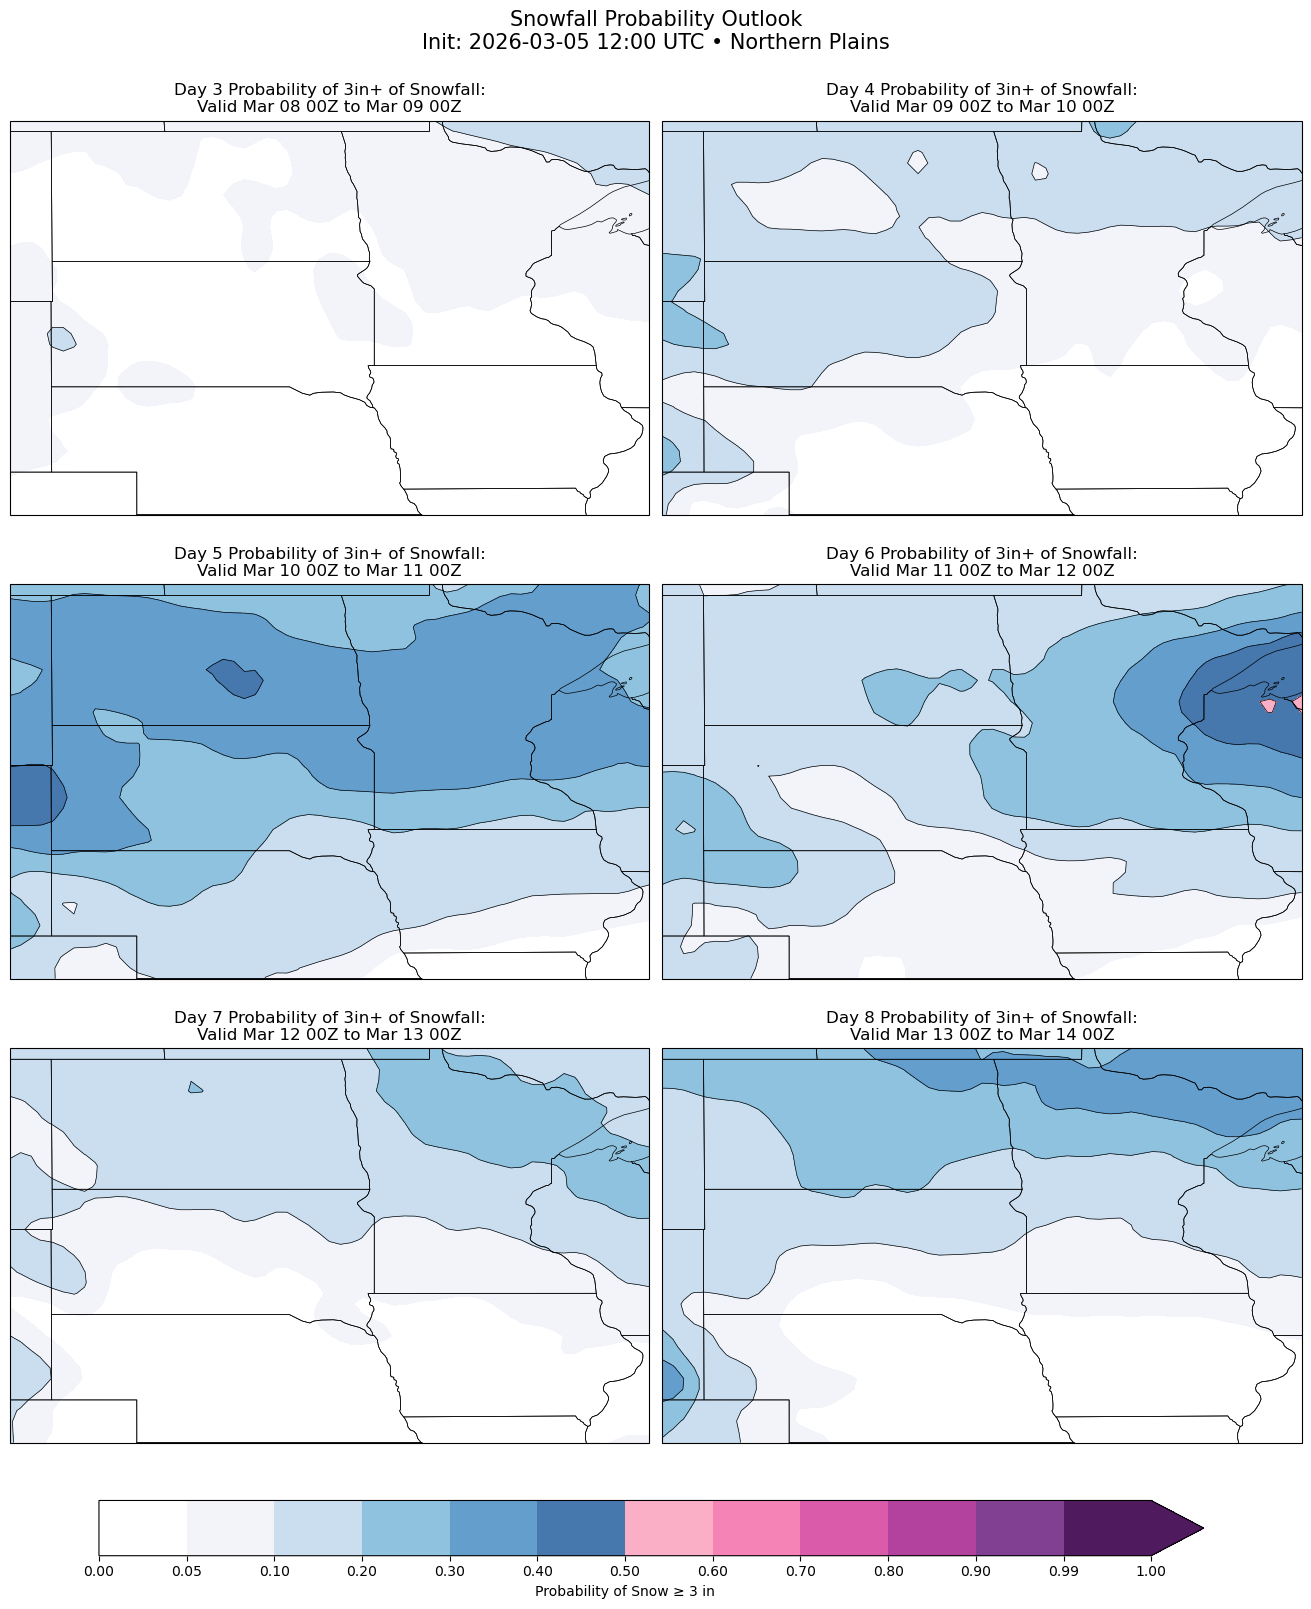

In [4]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.ndimage import gaussian_filter

# =====================================================
# CONFIG
# =====================================================

BASE_DIR = Path("/nfs/spare11/dharkin/NWS_Lapenta_Project/correct_parquet_data/Operational_data")
MODEL = Path("/nfs/spare11/dharkin/NWS_Lapenta_Project/models/rf_year2015-2019_3in_neighborhood_reshaped.joblib")

LAT_MIN, LAT_MAX = 40.0, 49.25
LON_MIN, LON_MAX = -105.0, -90.0
THRESH_CM = 7.62  # 6 inches
SMOOTH_SIGMA = 1.0

# =====================================================
# 1️⃣ Find latest MEAN parquet file
# =====================================================

all_parquets = list(BASE_DIR.rglob("*mean*.parquet"))

if not all_parquets:
    raise FileNotFoundError("No MEAN parquet files found.")

def extract_date(path):
    match = re.search(r"(\d{8})", path.name)
    if match:
        return pd.to_datetime(match.group(1), format="%Y%m%d")
    return pd.Timestamp.min

all_parquets_sorted = sorted(all_parquets, key=extract_date)
PARQUET = all_parquets_sorted[-1]

print(f"📂 Using latest MEAN parquet file:\n{PARQUET}")

# =====================================================
# 2️⃣ Load data
# =====================================================

df = pd.read_parquet(PARQUET)

df["longitude"] = df["longitude"].apply(
    lambda lon: lon - 360 if lon > 180 else lon
)

# =====================================================
# 3️⃣ Subset domain
# =====================================================

geo_mask = (
    df["latitude"].between(LAT_MIN, LAT_MAX) &
    df["longitude"].between(LON_MIN, LON_MAX)
)

df = df.loc[geo_mask]
print(f"Rows after spatial filter: {len(df)}")

# =====================================================
# 4️⃣ Compute forecast lead
# =====================================================

df["valid_time"] = pd.to_datetime(df["valid_time"])
df["init_time"] = pd.to_datetime(df["init_time"])

df["forecast_lead_hours"] = (
    (df["valid_time"] - df["init_time"]).dt.total_seconds() // 3600
)

df = df[df["forecast_lead_hours"].between(60, 204)]

if df.empty:
    raise ValueError("No forecast data found for hours 60–204.")

init_time = df["init_time"].min()

# =====================================================
# 5️⃣ Load trained model
# =====================================================

bundle = joblib.load(MODEL)
rf = bundle["model"]
feature_cols = bundle["features"]

for col in feature_cols:
    if col not in df.columns:
        df[col] = 0

X = df[feature_cols].astype("float32").fillna(0)
df["prob"] = rf.predict_proba(X)[:, 1]

# =====================================================
# 6️⃣ Build snow mask
# =====================================================

if "snowfall_nohrsc_m" in df.columns:
    df["snow_cm"] = df["snowfall_nohrsc_m"] * 100.0
else:
    df["snow_cm"] = np.nan

lats_sorted = np.sort(df["latitude"].unique())
lons_sorted = np.sort(df["longitude"].unique())

ny, nx = len(lats_sorted), len(lons_sorted)
lat_to_idx = {lat: i for i, lat in enumerate(lats_sorted)}
lon_to_idx = {lon: j for j, lon in enumerate(lons_sorted)}

snow_mask = np.full((ny, nx), False)

if not df["snow_cm"].isna().all():
    obs_agg = (
        df.groupby(["latitude", "longitude"])["snow_cm"]
        .mean()
        .reset_index()
    )

    snow_grid = np.full((ny, nx), np.nan)

    for lat, lon, s in obs_agg.itertuples(index=False):
        snow_grid[lat_to_idx[lat], lon_to_idx[lon]] = s

    snow_mask = snow_grid >= THRESH_CM

# =====================================================
# 7️⃣ Build Day 3–8 grids
# =====================================================

day_grids = {}
verify_times = {}

for day in range(3, 9):

    fh_start = 60 + (day - 3) * 24
    fh_end = fh_start + 24

    subset = df[
        (df["forecast_lead_hours"] >= fh_start) &
        (df["forecast_lead_hours"] <= fh_end)
    ]

    if subset.empty:
        continue

    agg = (
        subset.groupby(["latitude", "longitude"])["prob"]
        .mean()
        .reset_index()
    )

    grid = np.full((ny, nx), np.nan)

    for lat, lon, p in agg.itertuples(index=False):
        grid[lat_to_idx[lat], lon_to_idx[lon]] = p

    smoothed_grid = gaussian_filter(grid, sigma=SMOOTH_SIGMA)

    day_grids[day] = smoothed_grid
    verify_times[day] = init_time + pd.Timedelta(hours=int(fh_end))

if not day_grids:
    raise RuntimeError("No probability grids found.")

# =====================================================
# 8️⃣ Plot
# =====================================================

boundaries = [0, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50,
              0.60, 0.70, 0.80, 0.90, 0.99, 1.0]

colors = [
    "white", "#f3f4fa", "#cadef0", "#8fc2df", "#639ecd",
    "#4677ad", "#fbafc6", "#f583b6", "#da5baa",
    "#b2429d", "#814092", "#501b5e"
]

cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(boundaries, cmap.N)

proj = ccrs.PlateCarree()
extent = [LON_MIN, LON_MAX, LAT_MIN, LAT_MAX]
contour_lines = np.arange(0.1, 1.01, 0.10)

fig, axes = plt.subplots(
    3, 2, figsize=(13, 16),
    subplot_kw=dict(projection=proj),
    constrained_layout=True
)

axes = axes.flatten()

for ax, day in zip(axes, range(3, 9)):

    ax.set_extent(extent)
    ax.add_feature(cfeature.STATES.with_scale("50m"), lw=0.5)
    ax.coastlines("50m", lw=0.5)

    grid = day_grids.get(day)

    if grid is not None:
        c = ax.contourf(
            lons_sorted, lats_sorted, grid,
            levels=boundaries, cmap=cmap, norm=norm,
            extend="max", transform=proj
        )

        ax.contour(
            lons_sorted, lats_sorted, grid,
            levels=contour_lines,
            colors="black", linewidths=0.5,
            transform=proj
        )

        if snow_mask.any():
            ax.contourf(
                lons_sorted, lats_sorted, snow_mask,
                levels=[0.5, 1],
                colors="none", hatches=["////"],
                transform=proj, alpha=0
            )

        vt = verify_times.get(day)
        start_time = vt - pd.Timedelta(hours=24)

        title_str = (
            f"Day {day} Probability of 3in+ of Snowfall:\n"
            f"Valid {start_time.strftime('%b %d %HZ')} to "
            f"{vt.strftime('%b %d %HZ')}"
        )

        ax.set_title(title_str)

    else:
        ax.set_title(f"Day {day}: No Data")

fig.colorbar(
    c, ax=axes, orientation="horizontal",
    pad=0.04, fraction=0.04,
    label="Probability of Snow ≥ 3 in",
    boundaries=boundaries, ticks=boundaries
)

fig.suptitle(
    f"Snowfall Probability Outlook\n"
    f"Init: {init_time.strftime('%Y-%m-%d %H:%M UTC')} • Northern Plains",
    fontsize=15
)

plt.show()

In [5]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.ndimage import gaussian_filter

# =====================================================
# CONFIG
# =====================================================

BASE_DIR = Path("/nfs/spare11/dharkin/NWS_Lapenta_Project/correct_parquet_data/Operational_data")
MODEL = Path("/nfs/spare11/dharkin/NWS_Lapenta_Project/models/rf_year2015-2019_3in_neighborhood_reshaped.joblib")
OUTLOOK_BASE = Path("/nfs/spare11/dharkin/NWS_Lapenta_Project/Daily_Outlooks")

LAT_MIN, LAT_MAX = 40.0, 49.25
LON_MIN, LON_MAX = -105.0, -90.0
THRESH_CM = 7.62
SMOOTH_SIGMA = 1.0

# =====================================================
# 1️⃣ Find latest MEAN parquet
# =====================================================

all_parquets = list(BASE_DIR.rglob("*mean*.parquet"))

if not all_parquets:
    raise FileNotFoundError("No MEAN parquet files found.")

def extract_date(path):
    match = re.search(r"(\d{8})", path.name)
    if match:
        return pd.to_datetime(match.group(1), format="%Y%m%d")
    return pd.Timestamp.min

all_parquets_sorted = sorted(all_parquets, key=extract_date)
PARQUET = all_parquets_sorted[-1]

print(f"\n📂 Using latest MEAN parquet:\n{PARQUET}\n")

# =====================================================
# 2️⃣ Load data
# =====================================================

df = pd.read_parquet(PARQUET)

df["longitude"] = df["longitude"].apply(lambda lon: lon - 360 if lon > 180 else lon)

geo_mask = (
    df["latitude"].between(LAT_MIN, LAT_MAX) &
    df["longitude"].between(LON_MIN, LON_MAX)
)

df = df.loc[geo_mask]
print(f"Rows after spatial filter: {len(df)}")

# =====================================================
# 3️⃣ Forecast lead filtering
# =====================================================

df["valid_time"] = pd.to_datetime(df["valid_time"])
df["init_time"] = pd.to_datetime(df["init_time"])

df["forecast_lead_hours"] = (
    (df["valid_time"] - df["init_time"]).dt.total_seconds() // 3600
)

df = df[df["forecast_lead_hours"].between(60, 204)]

if df.empty:
    raise ValueError("No forecast data between 60–204h.")

init_time = df["init_time"].min()

# =====================================================
# 4️⃣ Load trained RF model
# =====================================================

bundle = joblib.load(MODEL)
rf = bundle["model"]
feature_cols = bundle["features"]

for col in feature_cols:
    if col not in df.columns:
        df[col] = 0

X = df[feature_cols].astype("float32").fillna(0)
df["prob"] = rf.predict_proba(X)[:, 1]

# =====================================================
# 5️⃣ Snow mask (optional)
# =====================================================

if "snowfall_nohrsc_m" in df.columns:
    df["snow_cm"] = df["snowfall_nohrsc_m"] * 100.0
else:
    df["snow_cm"] = np.nan

lats_sorted = np.sort(df["latitude"].unique())
lons_sorted = np.sort(df["longitude"].unique())

ny, nx = len(lats_sorted), len(lons_sorted)

lat_to_idx = {lat: i for i, lat in enumerate(lats_sorted)}
lon_to_idx = {lon: j for j, lon in enumerate(lons_sorted)}

snow_mask = np.full((ny, nx), False)

if not df["snow_cm"].isna().all():
    obs_agg = (
        df.groupby(["latitude", "longitude"])["snow_cm"]
        .mean()
        .reset_index()
    )

    snow_grid = np.full((ny, nx), np.nan)

    for lat, lon, s in obs_agg.itertuples(index=False):
        snow_grid[lat_to_idx[lat], lon_to_idx[lon]] = s

    snow_mask = snow_grid >= THRESH_CM

# =====================================================
# 6️⃣ Build Day 3–8 grids
# =====================================================

day_grids = {}
verify_times = {}

for day in range(3, 9):

    fh_start = 60 + (day - 3) * 24
    fh_end = fh_start + 24

    subset = df[
        (df["forecast_lead_hours"] >= fh_start) &
        (df["forecast_lead_hours"] <= fh_end)
    ]

    if subset.empty:
        continue

    agg = subset.groupby(["latitude", "longitude"])["prob"].mean().reset_index()
    grid = np.full((ny, nx), np.nan)

    for lat, lon, p in agg.itertuples(index=False):
        grid[lat_to_idx[lat], lon_to_idx[lon]] = p

    smoothed_grid = gaussian_filter(grid, sigma=SMOOTH_SIGMA)

    day_grids[day] = smoothed_grid
    verify_times[day] = init_time + pd.Timedelta(hours=int(fh_end))

if not day_grids:
    raise RuntimeError("No probability grids found.")

# =====================================================
# 7️⃣ Plot
# =====================================================

boundaries = [0, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50,
              0.60, 0.70, 0.80, 0.90, 0.99, 1.0]

colors = [
    "white", "#f3f4fa", "#cadef0", "#8fc2df", "#639ecd",
    "#4677ad", "#fbafc6", "#f583b6", "#da5baa",
    "#b2429d", "#814092", "#501b5e"
]

cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(boundaries, cmap.N)

proj = ccrs.PlateCarree()
extent = [LON_MIN, LON_MAX, LAT_MIN, LAT_MAX]
contour_lines = np.arange(0.1, 1.01, 0.10)

fig, axes = plt.subplots(
    3, 2,
    figsize=(13, 16),
    subplot_kw=dict(projection=proj),
    constrained_layout=True
)

axes = axes.flatten()

for ax, day in zip(axes, range(3, 9)):

    ax.set_extent(extent)
    ax.add_feature(cfeature.STATES.with_scale("50m"), lw=0.5)
    ax.coastlines("50m", lw=0.5)

    grid = day_grids.get(day)

    if grid is not None:

        c = ax.contourf(
            lons_sorted, lats_sorted, grid,
            levels=boundaries, cmap=cmap,
            norm=norm, extend="max",
            transform=proj
        )

        ax.contour(
            lons_sorted, lats_sorted, grid,
            levels=contour_lines,
            colors="black", linewidths=0.5,
            transform=proj
        )

        if snow_mask.any():
            ax.contourf(
                lons_sorted, lats_sorted, snow_mask,
                levels=[0.5, 1],
                colors="none", hatches=["////"],
                transform=proj, alpha=0
            )

        vt = verify_times.get(day)
        start_time = vt - pd.Timedelta(hours=24)

        # 🔥 NEW TITLE FORMAT
        title_str = (
            f"Day {day} Probability of 3in+ of Snowfall:\n"
            f"Valid {start_time.strftime('%b %d %HZ')} to "
            f"{vt.strftime('%b %d %HZ')}"
        )

        ax.set_title(title_str)

    else:
        ax.set_title(f"Day {day}: No Data")

fig.colorbar(
    c, ax=axes,
    orientation="horizontal",
    pad=0.04,
    fraction=0.04,
    label="Probability of Snow ≥ 6 in",
    boundaries=boundaries,
    ticks=boundaries
)

fig.suptitle(
    f"3 Inch Snowfall Probability Outlook\n"
    f"Init: {init_time.strftime('%Y-%m-%d %H:%M UTC')} • Northern Plains",
    fontsize=15
)

# =====================================================
# 8️⃣ Save Figure
# =====================================================

year = init_time.strftime("%Y")
month = init_time.strftime("%m")
day = init_time.strftime("%d")

save_dir = OUTLOOK_BASE / year / month / day
save_dir.mkdir(parents=True, exist_ok=True)

output_filename = f"3_inch_Snowfall_Prob_Outlook_{init_time.strftime('%Y%m%d_%Hz')}.png"
output_path = save_dir / output_filename

plt.savefig(output_path, dpi=200, bbox_inches="tight")
plt.close(fig)

print(f"\n✅ Outlook saved to:\n{output_path}\n")


📂 Using latest MEAN parquet:
/nfs/spare11/dharkin/NWS_Lapenta_Project/correct_parquet_data/Operational_data/2026/03/05/Operational_GEFS_12z_20260305_mean.parquet

Rows after spatial filter: 13908


/knight/jan25/envs/jan25_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(



✅ Outlook saved to:
/nfs/spare11/dharkin/NWS_Lapenta_Project/Daily_Outlooks/2026/03/05/3_inch_Snowfall_Prob_Outlook_20260305_12z.png

